In [2]:
! pip3 install torch torchvision


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Suryaprakash\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as f
import os
import numpy as np
from tqdm import tqdm

In [4]:
class SingleRNN(nn.Module):
    def __init__(self, n_inputs,n_neurons):
        super(SingleRNN, self).__init__()
        self.Wx = torch.randn(n_inputs, n_neurons) # 4 X 1
        self.Wy = torch.randn(n_neurons, n_neurons) # 1 X 1
        self.b = torch.randn(1, n_neurons) # 1 X 4

    def forward(self, X0, X1):
        self.Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b) # 1 X 4
        self.Y1 = torch.tanh(torch.mm(self.Y0, self.Wy) + torch.mm(X1, self.Wx) + self.b) # 1 X 4

        return self.Y0, self.Y1

In [5]:
N_INPUT = 4
N_NEURONS = 1

X0_batch = torch.tensor(
    [[0,1,2,0],[3,4,5,0],
    [6,7,8,0],[9,0,1,0]], dtype=torch.float)

X1_batch = torch.tensor(
    [[9,8,7,0],[0,0,0,0],
    [6,5,4,0],[3,2,1,0]], dtype=torch.float)

model = SingleRNN(N_INPUT, N_NEURONS)
Y0_val, Y1_val = model(X0_batch, X1_batch)

In [6]:
print(Y0_val)
print(Y1_val)

tensor([[-0.9217],
        [-0.9875],
        [-0.9981],
        [ 1.0000]])
tensor([[-0.1559],
        [ 0.4190],
        [ 0.6452],
        [ 0.9640]])


## Increasing Neurons in RNN Layer

In [7]:
class BasicRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(BasicRNN, self).__init__()
        
        self.Wx = torch.randn(n_inputs, n_neurons) # n_inputs X n_neurons
        self.Wy = torch.randn(n_neurons, n_neurons) # n_neurons X n_neurons
        
        self.b = torch.zeros(1, n_neurons) # 1 X n_neurons
    
    def forward(self, X0, X1):
        self.Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b) # batch_size X n_neurons
        
        self.Y1 = torch.tanh(torch.mm(self.Y0, self.Wy) +
                            torch.mm(X1, self.Wx) + self.b) # batch_size X n_neurons
        
        return self.Y0, self.Y1

In [8]:
N_INPUT = 3 # number of features in input
N_NEURONS = 5 # number of units in layer

X0_batch = torch.tensor([[0,1,2], [3,4,5], 
                         [6,7,8], [9,0,1]],
                        dtype = torch.float) #t=0 => 4 X 3

X1_batch = torch.tensor([[9,8,7], [0,0,0], 
                         [6,5,4], [3,2,1]],
                        dtype = torch.float) #t=1 => 4 X 3

model = BasicRNN(N_INPUT, N_NEURONS)

Y0_val, Y1_val = model(X0_batch, X1_batch)

In [9]:
print(Y0_val)
print(Y1_val)

tensor([[-0.5496, -0.9907,  0.9995, -0.9987, -0.9959],
        [-0.9998, -0.9997,  1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000,  1.0000, -1.0000, -1.0000],
        [-1.0000,  0.9998,  1.0000,  0.9732,  0.9859]])
tensor([[-1.0000, -0.9868,  1.0000, -1.0000, -1.0000],
        [-0.6358,  0.4611, -0.9207,  0.9808,  0.4325],
        [-1.0000, -0.4102,  1.0000, -1.0000, -1.0000],
        [-0.9996, -0.9233,  1.0000,  0.7087, -0.9998]])


## Py-torch built in RNN Cell

In [10]:
rnn = nn.RNNCell(3, 5) # n_input X n_neurons

X_batch = torch.tensor([[[0,1,2], [3,4,5], 
                         [6,7,8], [9,0,1]],
                        [[9,8,7], [0,0,0], 
                         [6,5,4], [3,2,1]]
                       ], dtype = torch.float) # X0 and X1

hx = torch.randn(4, 5) # m X n_neurons
output = []

# for each time step
for i in range(2):
    hx = rnn(X_batch[i], hx)
    output.append(hx)

print(output)

[tensor([[-0.6681,  0.6436,  0.4599, -0.6629, -0.7594],
        [ 0.9840,  0.9983, -0.6375, -0.9363,  0.5077],
        [ 0.7686,  0.9984, -0.6255, -0.9999, -0.8404],
        [ 0.9092,  0.9857, -0.9769, -0.7307,  0.9955]],
       grad_fn=<TanhBackward0>), tensor([[ 0.6513,  0.9997, -0.9186, -1.0000,  0.6102],
        [ 0.4643,  0.6306, -0.4546,  0.0449, -0.0115],
        [ 0.8757,  0.9976, -0.9234, -0.9958,  0.6937],
        [ 0.5391,  0.8732, -0.8703, -0.9046, -0.0024]],
       grad_fn=<TanhBackward0>)]


In [11]:
class CleanBasicRNN(nn.Module):
    def __init__(self, batch_size, n_inputs, n_neurons):
        super(CleanBasicRNN, self).__init__()
        
        self.rnn = nn.RNNCell(n_inputs, n_neurons)
        self.hx = torch.randn(batch_size, n_neurons) # initialize hidden state
        
    def forward(self, X):
        output = []

        # for each time step
        for i in range(2):
            self.hx = self.rnn(X[i], self.hx)
            output.append(self.hx)
        
        return output, self.hx

In [12]:
FIXED_BATCH_SIZE = 4 # our batch size is fixed for now
N_INPUT = 3
N_NEURONS = 5

X_batch = torch.tensor([[[0,1,2], [3,4,5], 
                         [6,7,8], [9,0,1]],
                        [[9,8,7], [0,0,0], 
                         [6,5,4], [3,2,1]]
                       ], dtype = torch.float) # X0 and X1


model = CleanBasicRNN(FIXED_BATCH_SIZE, N_INPUT, N_NEURONS)
output_val, states_val = model(X_batch)
print(output_val) # contains all output for all timesteps
print(states_val) # contain values for final state or final timestep, i.e., t=1

[tensor([[ 0.9543,  0.7451, -0.2581, -0.1849,  0.2511],
        [ 0.9998,  0.9989, -0.9775,  0.5753, -0.7132],
        [ 1.0000,  0.9999, -0.6057, -0.5359,  0.9840],
        [ 0.9989,  0.9991,  0.3159, -0.3199, -0.8780]],
       grad_fn=<TanhBackward0>), tensor([[ 1.0000,  1.0000, -0.9566,  0.9202,  0.8771],
        [ 0.5902, -0.7684,  0.4967,  0.9562,  0.1336],
        [ 1.0000,  0.9994, -0.7656,  0.9034,  0.7518],
        [ 0.9836,  0.8549,  0.0103,  0.9551,  0.4016]],
       grad_fn=<TanhBackward0>)]
tensor([[ 1.0000,  1.0000, -0.9566,  0.9202,  0.8771],
        [ 0.5902, -0.7684,  0.4967,  0.9562,  0.1336],
        [ 1.0000,  0.9994, -0.7656,  0.9034,  0.7518],
        [ 0.9836,  0.8549,  0.0103,  0.9551,  0.4016]],
       grad_fn=<TanhBackward0>)


## RNN for image classification

In [13]:
import torchvision
import torchvision.transforms as transforms

In [14]:
BATCH_SIZE = 64

# list all transformations
transform = transforms.Compose(
    [transforms.ToTensor()])

# download and load training dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

# download and load testing dataset
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 105kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 875kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.26MB/s]


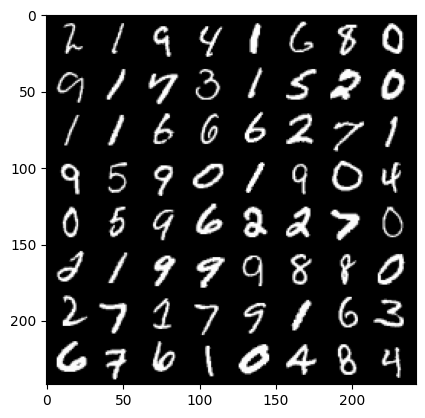

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

## Model


In [16]:
# parameters 
N_STEPS = 28
N_INPUTS = 28
N_NEURONS = 150
N_OUTPUTS = 10
N_EPHOCS = 10

In [17]:
class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
        super(ImageRNN, self).__init__()
        
        self.n_neurons = n_neurons
        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        
        self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons) 
        
        self.FC = nn.Linear(self.n_neurons, self.n_outputs)
        
    def init_hidden(self,):
        # (num_layers, batch_size, n_neurons)
        return (torch.zeros(1, self.batch_size, self.n_neurons))
        
    def forward(self, X):
        # transforms X to dimensions: n_steps X batch_size X n_inputs
        X = X.permute(1, 0, 2) 
        
        self.batch_size = X.size(1)
        self.hidden = self.init_hidden()
        
        # lstm_out => n_steps, batch_size, n_neurons (hidden states for each time step)
        # self.hidden => 1, batch_size, n_neurons (final state from each lstm_out)
        lstm_out, self.hidden = self.basic_rnn(X, self.hidden)      
        out = self.FC(self.hidden)
        
        return out.view(-1, self.n_outputs) # batch_size X n_output

## Testing the model with some examples

In [18]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
logits = model(images.view(-1, 28,28))
print(logits[0:10])

tensor([[ 0.0449,  0.0072,  0.0541,  0.0144,  0.0565,  0.0844,  0.0528,  0.0683,
         -0.0744,  0.0302],
        [ 0.0330, -0.0005,  0.0938,  0.0673,  0.0070,  0.0830,  0.0429,  0.0493,
         -0.0824,  0.0381],
        [ 0.0355,  0.0120,  0.0660,  0.0344,  0.0479,  0.0928,  0.0306,  0.0816,
         -0.0712,  0.0069],
        [ 0.0443,  0.0038,  0.0534,  0.0424,  0.0291,  0.0832,  0.0536,  0.0583,
         -0.0795,  0.0208],
        [ 0.0401, -0.0002,  0.0443,  0.0428,  0.0408,  0.0888,  0.0523,  0.0620,
         -0.0759,  0.0117],
        [ 0.0415, -0.0018,  0.0468,  0.0424,  0.0445,  0.0942,  0.0419,  0.0680,
         -0.0763,  0.0132],
        [ 0.0515,  0.0086,  0.0503,  0.0346,  0.0328,  0.0880,  0.0800,  0.0487,
         -0.0847,  0.0070],
        [ 0.0331,  0.0046,  0.0438,  0.0446,  0.0434,  0.0869,  0.0508,  0.0612,
         -0.0716,  0.0092],
        [ 0.0424, -0.0021,  0.0484,  0.0393,  0.0314,  0.0836,  0.0484,  0.0678,
         -0.0754,  0.0110],
        [ 0.0390, -

## Training

In [19]:
import torch.optim as optim

# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Model instance
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def get_accuracy(logit, target, batch_size):
    ''' Obtain accuracy for training round '''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects/batch_size
    return accuracy.item()

In [20]:
for epoch in range(N_EPHOCS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()
    
    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()
        
        # reset hidden states
        model.hidden = model.init_hidden() 
        
        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28) 

        # forward + backward + optimize
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, BATCH_SIZE)
         
    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f' 
          %(epoch, train_running_loss / i, train_acc/i))

Epoch:  0 | Loss: 0.8119 | Train Accuracy: 72.33
Epoch:  1 | Loss: 0.3319 | Train Accuracy: 90.24
Epoch:  2 | Loss: 0.2361 | Train Accuracy: 93.07
Epoch:  3 | Loss: 0.1865 | Train Accuracy: 94.84
Epoch:  4 | Loss: 0.1732 | Train Accuracy: 95.12
Epoch:  5 | Loss: 0.1545 | Train Accuracy: 95.72
Epoch:  6 | Loss: 0.1419 | Train Accuracy: 96.01
Epoch:  7 | Loss: 0.1365 | Train Accuracy: 96.12
Epoch:  8 | Loss: 0.1227 | Train Accuracy: 96.57
Epoch:  9 | Loss: 0.1168 | Train Accuracy: 96.74


In [21]:
test_acc = 0.0
for i, data in enumerate(testloader, 0):
    inputs, labels = data
    inputs = inputs.view(-1, 28, 28)

    outputs = model(inputs)

    test_acc += get_accuracy(outputs, labels, BATCH_SIZE)
        
print('Test Accuracy: %.2f'%( test_acc/i))

Test Accuracy: 96.25
